In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Install pvlib if not present for astronomical solar position calculation
try:
    import pvlib
except ImportError:
    !pip install -q pvlib
    import pvlib

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

In [14]:
# Data search paths (handles Google Drive, Colab local, and workspace environments)
hdf5_paths = [
    "/content/data/2017_2019_images_pv_defisheye.hdf5",
    "/content/drive/MyDrive/solar_data/2017_2019_images_pv_defisheye.hdf5",
]

hdf5_path = None
for p in hdf5_paths:
    if os.path.exists(p):
        hdf5_path = p
        break

# Extracted directory fallback
data_dir = (
    "/content/data/extracted/" if os.path.exists("/content/data/extracted/") else "./"
)

if hdf5_path:
    print(f"Loading directly from HDF5: {hdf5_path}")
    f_h5 = h5py.File(hdf5_path, "r")
    trainval_images = f_h5["trainval"]["images_log"]
    trainval_pv = np.array(f_h5["trainval"]["pv_log"])
    test_images = f_h5["test"]["images_log"]
    test_pv = np.array(f_h5["test"]["pv_log"])
else:
    print("Loading from extracted .npy files...")
    # Try defisheyed first, then processed
    tv_img_p = os.path.join(data_dir, "trainval_images_defisheye.npy")
    if not os.path.exists(tv_img_p):
        tv_img_p = os.path.join(data_dir, "trainval_images_log.npy")
    trainval_images = np.load(tv_img_p, mmap_mode="r")
    trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy"))

    te_img_p = os.path.join(data_dir, "test_images_defisheye.npy")
    if not os.path.exists(te_img_p):
        te_img_p = os.path.join(data_dir, "test_images_log.npy")
    test_images = np.load(te_img_p, mmap_mode="r")
    test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy"))

# Load timestamps
for t_path in [
    "/content/data/times_trainval.npy",
    "/content/drive/MyDrive/solar_data/times_trainval.npy",
    "times_trainval.npy",
]:
    if os.path.exists(t_path):
        trainval_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    trainval_times = None

for t_path in [
    "/content/data/times_test.npy",
    "/content/drive/MyDrive/solar_data/times_test.npy",
    "times_test.npy",
]:
    if os.path.exists(t_path):
        test_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    test_times = None

print(f"Train/Val Images: {trainval_images.shape} | PV: {trainval_pv.shape}")
print(f"Test Images:     {test_images.shape} | PV: {test_pv.shape}")
if trainval_times is not None:
    print(f"Train/Val Dates:  {trainval_times[0]} to {trainval_times[-1]}")
if test_times is not None:
    print(f"Test Dates:       {test_times[0]} to {test_times[-1]}")

Loading from extracted .npy files...
Train/Val Images: (349372, 64, 64, 3) | PV: (349372,)
Test Images:     (14003, 64, 64, 3) | PV: (14003,)
Train/Val Dates:  2017-03-09 06:47:00 to 2019-10-26 17:59:20
Test Dates:       2017-09-15 07:11:00 to 2019-10-19 18:15:30


In [23]:
# Show a random sample from all images

rng = np.random.default_rng(np.random.choice(range(1, 10000)))

# Randomly choose train/val or test
split = rng.choice(["trainval", "test"])

if split == "trainval":
    idx = rng.integers(0, len(trainval_images))
    image = np.array(trainval_images[idx])
    pv = trainval_pv[idx]
    timestamp = trainval_times[idx] if trainval_times is not None else None
else:
    idx = rng.integers(0, len(test_images))
    image = np.array(test_images[idx])
    pv = test_pv[idx]
    timestamp = test_times[idx] if test_times is not None else None

print("Split:", split)
print("Random index:", idx)
print("Image shape:", image.shape)
print("PV value:", pv)
print("Timestamp:", timestamp)
print("Image array:")
print(image)

Split: trainval
Random index: 243069
Image shape: (64, 64, 3)
PV value: 8.472960341
Timestamp: 2019-06-01 18:11:30
Image array:
[[[  0   0   0]
  [  0   0   0]
  [117 117 117]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 ...

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]]


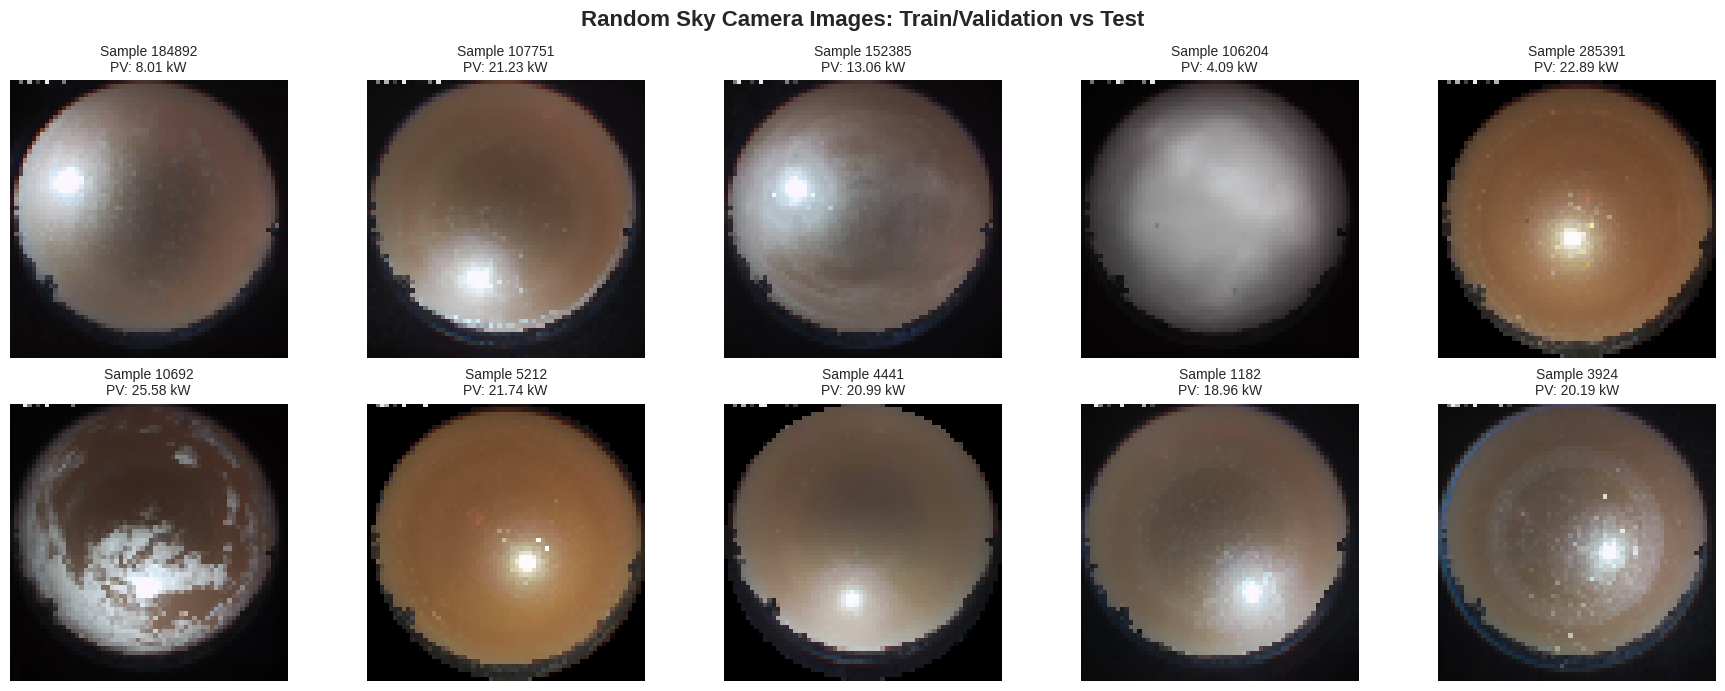

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def format_img(img):
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))

    if img.max() > 1.0 and img.dtype != np.uint8:
        img = img / 255.0

    return img


num_samples = 5

train_indices = np.random.choice(len(trainval_images), size=num_samples, replace=False)

test_indices = np.random.choice(len(test_images), size=num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(18, 7))

fig.suptitle(
    "Random Sky Camera Images: Train/Validation vs Test", fontsize=16, fontweight="bold"
)

for col, idx in enumerate(train_indices):

    axes[0, col].imshow(format_img(trainval_images[idx]))

    pv_val = trainval_pv[idx]

    axes[0, col].set_title(f"Sample {idx}\nPV: {pv_val:.2f} kW", fontsize=10)

    axes[0, col].axis("off")


for col, idx in enumerate(test_indices):

    axes[1, col].imshow(format_img(test_images[idx]))

    pv_val = test_pv[idx]

    axes[1, col].set_title(f"Sample {idx}\nPV: {pv_val:.2f} kW", fontsize=10)

    axes[1, col].axis("off")


axes[0, 0].set_ylabel("Train / Validation", fontsize=12, fontweight="bold")

axes[1, 0].set_ylabel("Test", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()